<a href="https://colab.research.google.com/github/safiraroha26/student-clustering/blob/main/student_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA LOADING

In [ ]:
import pandas as pd

data = [
["A1",1,60,55,58,0],
["A2",2,65,60,62,0],
["A3",2,70,65,68,0],
["A4",3,75,70,72,1],
["A5",4,80,75,78,1],
["A6",5,85,80,85,1],
["A7",6,90,88,90,1],
["A8",1,55,50,54,0],
["A9",3,78,72,75,1],
["A10",2,68,63,66,0],
["A11",4,82,77,80,1],
["A12",5,88,85,87,1],
["A13",6,92,90,93,1],
["A14",1,58,52,56,0],
["A15",3,72,68,70,1]
]

columns = ["Nama","Jam_Belajar","Kehadiran","Nilai_Tugas","Nilai_Ujian","Status_Lulus"]

df = pd.DataFrame(data, columns=columns)

df

,Nama,Jam_Belajar,Kehadiran,Nilai_Tugas,Nilai_Ujian,Status_Lulus
0,A1,1,60,55,58,0
1,A2,2,65,60,62,0
2,A3,2,70,65,68,0
3,A4,3,75,70,72,1
4,A5,4,80,75,78,1
5,A6,5,85,80,85,1
6,A7,6,90,88,90,1
7,A8,1,55,50,54,0
8,A9,3,78,72,75,1
9,A10,2,68,63,66,0


# DATA CLEANING

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nInfo Dataset:")
print(df.info())

Missing Values:
Nama            0
Jam_Belajar     0
Kehadiran       0
Nilai_Tugas     0
Nilai_Ujian     0
Status_Lulus    0
dtype: int64

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Nama          15 non-null     object
 1   Jam_Belajar   15 non-null     int64 
 2   Kehadiran     15 non-null     int64 
 3   Nilai_Tugas   15 non-null     int64 
 4   Nilai_Ujian   15 non-null     int64 
 5   Status_Lulus  15 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 852.0+ bytes
None


# FEATURE SELECTION

In [ ]:
X = df[["Jam_Belajar","Kehadiran","Nilai_Tugas","Nilai_Ujian"]]

# STANDARDIZATION

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# MODELLING (K=2)

In [ ]:
from sklearn.cluster import KMeans

kmeans2 = KMeans(n_clusters=2, random_state=42)
df["Cluster_k2"] = kmeans2.fit_predict(X_scaled)

df

,Nama,Jam_Belajar,Kehadiran,Nilai_Tugas,Nilai_Ujian,Status_Lulus,Cluster_k2
0,A1,1,60,55,58,0,1
1,A2,2,65,60,62,0,1
2,A3,2,70,65,68,0,1
3,A4,3,75,70,72,1,1
4,A5,4,80,75,78,1,0
5,A6,5,85,80,85,1,0
6,A7,6,90,88,90,1,0
7,A8,1,55,50,54,0,1
8,A9,3,78,72,75,1,1
9,A10,2,68,63,66,0,1


# ANALISIS HASIL K=2

In [ ]:
df.groupby("Cluster_k2")[["Jam_Belajar","Kehadiran","Nilai_Tugas","Nilai_Ujian"]].mean()

,Jam_Belajar,Kehadiran,Nilai_Tugas,Nilai_Ujian
Cluster_k2,,,,
0,5.0,86.166667,82.500000,85.500000
1,2.0,66.777778,61.666667,64.555556


In [ ]:
#perbandingan dgn status_lulus
pd.crosstab(df["Cluster_k2"], df["Status_Lulus"])

Status_Lulus,0,1
Cluster_k2,,
0,0,6
1,6,3


# VISUALISASI

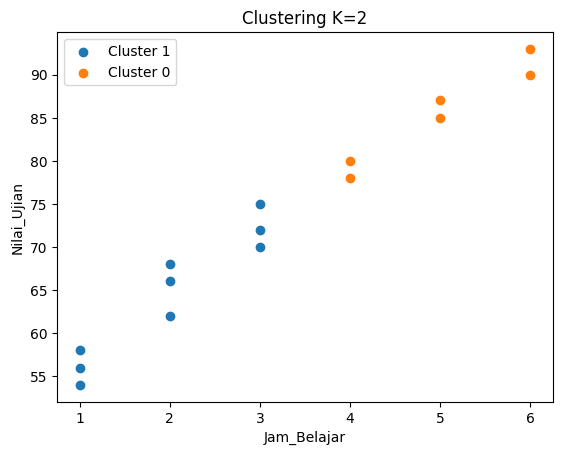

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for cluster in df["Cluster_k2"].unique():
    subset = df[df["Cluster_k2"] == cluster]
    plt.scatter(subset["Jam_Belajar"], subset["Nilai_Ujian"], label=f"Cluster {cluster}")

plt.xlabel("Jam_Belajar")
plt.ylabel("Nilai_Ujian")
plt.title("Clustering K=2")
plt.legend()
plt.show()

# MODELLING (K=3)

In [ ]:
kmeans3 = KMeans(n_clusters=3, random_state=42)
df["Cluster_k3"] = kmeans3.fit_predict(X_scaled)

df

,Nama,Jam_Belajar,Kehadiran,Nilai_Tugas,Nilai_Ujian,Status_Lulus,Cluster_k2,Cluster_k3
0,A1,1,60,55,58,0,1,2
1,A2,2,65,60,62,0,1,1
2,A3,2,70,65,68,0,1,1
3,A4,3,75,70,72,1,1,1
4,A5,4,80,75,78,1,0,0
5,A6,5,85,80,85,1,0,0
6,A7,6,90,88,90,1,0,0
7,A8,1,55,50,54,0,1,2
8,A9,3,78,72,75,1,1,1
9,A10,2,68,63,66,0,1,1


# ANALISIS K=3

In [ ]:
df.groupby("Cluster_k3")[["Jam_Belajar","Kehadiran","Nilai_Tugas","Nilai_Ujian"]].mean()

pd.crosstab(df["Cluster_k3"], df["Status_Lulus"])

# VISUALISASI K=3

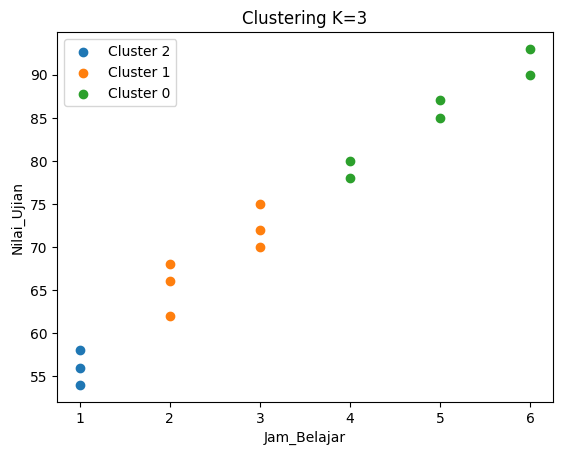

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for cluster in df["Cluster_k3"].unique():
    subset = df[df["Cluster_k3"] == cluster]
    plt.scatter(subset["Jam_Belajar"], subset["Nilai_Ujian"], label=f"Cluster {cluster}")

plt.xlabel("Jam_Belajar")
plt.ylabel("Nilai_Ujian")
plt.title("Clustering K=3")
plt.legend()
plt.show()